In [1]:
!pip install torchnet tensorboardX

from collections import OrderedDict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR, ConstantLR
from torchvision import transforms, models, datasets
from PIL import Image
from torchnet.meter import ClassErrorMeter
from tensorboardX import SummaryWriter
import torch.backends.cudnn as cudnn
import torch.utils.data as data
import torch.utils.model_zoo as model_zoo
import numpy as np
import torch.nn.functional as F
from torch.autograd import Variable
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
import math
import copy


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
def pil_loader(path):
    with open(path, 'rb') as f:
        with Image.open(f) as img:
            return img.convert('RGB')

def default_loader(path):
    from torchvision import get_image_backend
    if get_image_backend() == 'accimage':
        raise RuntimeError('No Module named accimage')
    else:
        return pil_loader(path)

class ImageNetData(data.Dataset):

    def __init__(self, img_root, img_file, is_training=False, transform=None, target_transform=None, loader=default_loader):
        self.root = img_root
        self.imgs = []
        with open(img_file, 'r', encoding='utf-8') as fd:
            for (i, _line) in enumerate(fd.readlines()):
                infos = _line.replace('\n', '').split('\t')
                if 2 != len(infos):
                    continue
                if is_training:
                    real_path = os.path.join(self.root, 't256', infos[0])
                else:
                    real_path = os.path.join(self.root, 'v256', infos[0])
                class_id = int(infos[-1])
                self.imgs.append((real_path, class_id))
        self.transform = transform
        self.target_transform = target_transform
        self.loader = loader

    def __getitem__(self, index):
        (path, class_id) = self.imgs[index]
        img = self.loader(path)
        if self.transform is not None:
            img = self.transform(img)
        if self.target_transform is not None:
            class_id = torch.LongTensor([class_id])
        return (img, class_id)

    def __len__(self):
        return len(self.imgs)


In [3]:
def count_images_per_class(dataloader):
    class_counts = {}
    class_to_idx = dataloader.dataset.class_to_idx
    idx_to_class = {v: k for (k, v) in class_to_idx.items()}
    for (class_name, idx) in class_to_idx.items():
        class_counts[idx] = 0
    for (_, labels) in tqdm(dataloader, desc='Counting images per class'):
        for label in labels:
            class_idx = label.item()
            class_counts[class_idx] += 1
    return class_counts

def calculate_class_weights(class_counts, weight_type='inverse'):
    counts = []
    class_indices = []
    for (class_idx, count) in class_counts.items():
        counts.append(count)
        class_indices.append(class_idx)
    sorted_indices = sorted(zip(class_indices, counts))
    class_indices = [pair[0] for pair in sorted_indices]
    counts = [pair[1] for pair in sorted_indices]
    counts = np.array(counts)
    if weight_type == 'inverse':
        weights = 1.0 / counts
    elif weight_type == 'sqrt_inverse':
        weights = 1.0 / np.sqrt(counts)
    else:
        raise ValueError("Invalid weight type. Choose 'inverse' or 'sqrt_inverse'.")
    weights = weights / np.sum(weights) * len(class_counts)
    class_weights = torch.tensor(weights, dtype=torch.float)
    return class_weights

class Trainer:

    def __init__(self, model, dataloaders, dataset_sizes, criterion, optimizer, scheduler=None, device=None, num_epochs=25, save_path=None):
        super().__init__()
        self.dataloaders = dataloaders
        self.dataset_sizes = dataset_sizes
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.num_epochs = num_epochs
        self.save_path = save_path
        self.best_model = copy.deepcopy(model.state_dict())
        self.best_acc = 0.0
        self.best_val_loss = float('inf')
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        self.model = model.to(self.device)

    def train(self):
        since = time.time()
        for epoch in range(self.num_epochs):
            print(f'Epoch {epoch + 1}/{self.num_epochs}')
            print('-' * 10)
            epoch_start = time.time()
            for phase in ['train', 'test']:
                if phase == 'train':
                    self.model.train()
                else:
                    self.model.eval()
                running_loss = 0.0
                running_corrects = 0
                dataloader = self.dataloaders[phase]
                progress_bar = tqdm(dataloader, desc=f'{phase} epoch {epoch + 1}/{self.num_epochs}', unit='batch')
                seen_samples = 0
                for (inputs, labels) in progress_bar:
                    inputs = inputs.to(self.device)
                    labels = labels.to(self.device)
                    self.optimizer.zero_grad()
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = self.model(inputs)
                        if isinstance(outputs, tuple) and len(outputs) == 2:
                            (main_output, aux_output) = outputs
                            main_loss = self.criterion(main_output, labels)
                            aux_loss = self.criterion(aux_output, labels)
                            loss = main_loss + 0.4 * aux_loss
                            (_, preds) = torch.max(main_output, 1)
                        else:
                            loss = self.criterion(outputs, labels)
                            (_, preds) = torch.max(outputs, 1)
                        if phase == 'train':
                            loss.backward()
                            self.optimizer.step()
                        running_loss += loss.item() * inputs.size(0)
                        running_corrects += torch.sum(preds == labels.data)
                        seen_samples += inputs.size(0)
                        current_loss = running_loss / seen_samples
                        progress_bar.set_postfix(loss=f'{current_loss:.4f}')
                if phase == 'train' and self.scheduler is not None:
                    self.scheduler.step()
                epoch_loss = running_loss / self.dataset_sizes[phase]
                epoch_acc = running_corrects.double() / self.dataset_sizes[phase]
                if phase == 'train':
                    self.history['train_loss'].append(epoch_loss)
                    self.history['train_acc'].append(epoch_acc.item())
                else:
                    self.history['val_loss'].append(epoch_loss)
                    self.history['val_acc'].append(epoch_acc.item())
                if phase == 'test':
                    if epoch_acc > self.best_acc:
                        self.best_acc = epoch_acc
                        self.best_model = copy.deepcopy(self.model.state_dict())
                    if epoch_loss < self.best_val_loss:
                        self.best_val_loss = epoch_loss
                        if self.save_path:
                            torch.save(self.model.state_dict(), self.save_path)
                            print(f'Model saved to {self.save_path}')
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            epoch_end = time.time()
            print(f'Epoch {epoch + 1} completed in {epoch_end - epoch_start:.0f} seconds')
        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best test Acc: {self.best_acc:.4f}')
        print(f'Best test Loss: {self.best_val_loss:.4f}')
        self.model.load_state_dict(self.best_model)
        return (self.model, self.history)

    def plot_history(self):
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.plot(self.history['train_loss'], label='Train Loss')
        plt.plot(self.history['val_loss'], label='Validation Loss')
        plt.title('Loss over epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(self.history['train_acc'], label='Train Accuracy')
        plt.plot(self.history['val_acc'], label='Validation Accuracy')
        plt.title('Accuracy over epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.tight_layout()
        plt.show()


In [4]:
import torch
import torch.nn as nn
import torch.utils.model_zoo as model_zoo
import math
import warnings
model_urls = {'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth', 'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth', 'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth', 'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth', 'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth'}

def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)

class ChannelAttention(nn.Module):

    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(nn.Conv2d(in_planes, in_planes // 16, 1, bias=False), nn.ReLU(), nn.Conv2d(in_planes // 16, in_planes, 1, bias=False))
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):

    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        (max_out, _) = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.ca = ChannelAttention(planes)
        self.sa = SpatialAttention()
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.ca(out) * out
        out = self.sa(out) * out
        if self.downsample is not None:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.ca = ChannelAttention(planes * 4)
        self.sa = SpatialAttention()
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        out = self.ca(out) * out
        out = self.sa(out) * out
        if self.downsample is not None:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000):
        self.inplanes = 64
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2.0 / n))
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False), nn.BatchNorm2d(planes * block.expansion))
        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

def _resnet_cbam(arch, block, layers, pretrained, **kwargs):
    model = ResNet(block, layers, **kwargs)
    if pretrained:
        state_dict = model_zoo.load_url(model_urls[arch])
        model.load_state_dict(state_dict, strict=False)
    return model

def resnet18_cbam(pretrained=False, **kwargs):
    """Constructs a ResNet-18 model with CBAM."""
    return _resnet_cbam('resnet18', BasicBlock, [2, 2, 2, 2], pretrained, **kwargs)

def resnet34_cbam(pretrained=False, **kwargs):
    """Constructs a ResNet-34 model with CBAM."""
    return _resnet_cbam('resnet34', BasicBlock, [3, 4, 6, 3], pretrained, **kwargs)

def resnet50_cbam(pretrained=False, **kwargs):
    """Constructs a ResNet-50 model with CBAM."""
    return _resnet_cbam('resnet50', Bottleneck, [3, 4, 6, 3], pretrained, **kwargs)

def resnet101_cbam(pretrained=False, **kwargs):
    """Constructs a ResNet-101 model with CBAM."""
    return _resnet_cbam('resnet101', Bottleneck, [3, 4, 23, 3], pretrained, **kwargs)

def resnet152_cbam(pretrained=False, **kwargs):
    """Constructs a ResNet-152 model with CBAM."""
    return _resnet_cbam('resnet152', Bottleneck, [3, 8, 36, 3], pretrained, **kwargs)


In [5]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.201))])
train_dataset = datasets.CIFAR10(root='/kaggle/working/', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='/kaggle/working/', train=False, download=True, transform=transform)
dataloaders = {'train': data.DataLoader(train_dataset, batch_size=64, shuffle=True), 'test': data.DataLoader(test_dataset, batch_size=64, shuffle=False)}
dataset_sizes = {'train': len(train_dataset), 'test': len(test_dataset)}
class_names = train_dataset.classes
num_classes = len(class_names)
print('MNIST Data Prepared:')
print('Number of classes:', num_classes)
print('Train set size:', dataset_sizes['train'])
print('Test set size:', dataset_sizes['test'])


100%|██████████| 170M/170M [00:02<00:00, 65.4MB/s]


MNIST Data Prepared:
Number of classes: 10
Train set size: 50000
Test set size: 10000


In [6]:
model = resnet50_cbam(pretrained=True, num_classes=1000)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.cuda()
num_epochs = 20
total_steps = num_epochs * len(dataloaders['train'])
MAX_LR = 0.001
optimizer = optim.Adam(model.parameters(), lr=MAX_LR)
loss = nn.CrossEntropyLoss()
warmup_steps = max(10, int(0.05 * total_steps))
decay_steps = int(0.05 * total_steps)
steady_steps = total_steps - warmup_steps - decay_steps
warmup_scheduler = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_steps)
steady_scheduler = ConstantLR(optimizer, factor=1.0, total_iters=steady_steps)
decay_scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.05, total_iters=decay_steps)
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, steady_scheduler, decay_scheduler], milestones=[warmup_steps, warmup_steps + steady_steps])
device = torch.device('cuda')


Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


Epoch 1/20
----------


train epoch 1/20: 100%|██████████| 782/782 [01:02<00:00, 12.52batch/s, loss=0.9122]


train Loss: 0.9122 Acc: 0.6865


test epoch 1/20: 100%|██████████| 157/157 [00:05<00:00, 29.43batch/s, loss=0.5698]


Model saved to /kaggle/working/best_model1.pth
test Loss: 0.5698 Acc: 0.8048
Epoch 1 completed in 68 seconds
Epoch 2/20
----------


...

test Loss: 0.7664 Acc: 0.8372
Epoch 19 completed in 68 seconds
Epoch 20/20
----------


train epoch 20/20: 100%|██████████| 782/782 [01:02<00:00, 12.49batch/s, loss=0.0377]


train Loss: 0.0377 Acc: 0.9876


test epoch 20/20: 100%|██████████| 157/157 [00:05<00:00, 29.44batch/s, loss=0.7033]


test Loss: 0.7033 Acc: 0.8492
Epoch 20 completed in 68 seconds
Training complete in 22m 42s
Best test Acc: 0.8492
Best test Loss: 0.4921


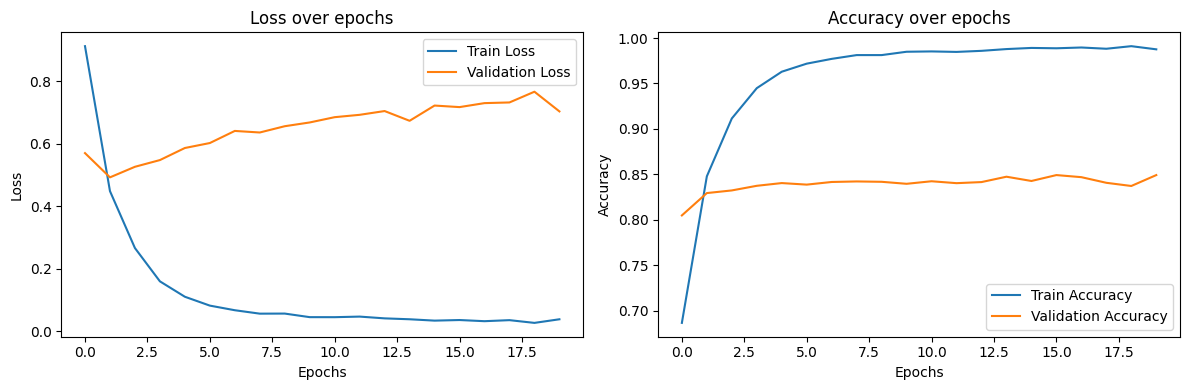

In [7]:
trainer = Trainer(model, dataloaders=dataloaders, dataset_sizes=dataset_sizes, criterion=loss, optimizer=optimizer, scheduler=scheduler, device=device, num_epochs=num_epochs, save_path='/kaggle/working/best_model1.pth')
trainer.train()
trainer.plot_history()
